 Téléchargement et extraction du dataset Oxford-IIIT Pet...


100%|██████████| 792M/792M [00:30<00:00, 25.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.29MB/s]


Dataset prêt et structuré dans /content/data !

Nombre total d'images chargées pour l'entraînement/validation : 3680

Calcul de la distribution réelle des pixels à partir de 200 masques...

===  DISTRIBUTION DES CLASSES (Q1) ===
Classe 0: Intérieur/Animal : 31.22% des pixels
Classe 1: Extérieur/Fond : 56.88% des pixels
Classe 2: Contour : 11.90% des pixels


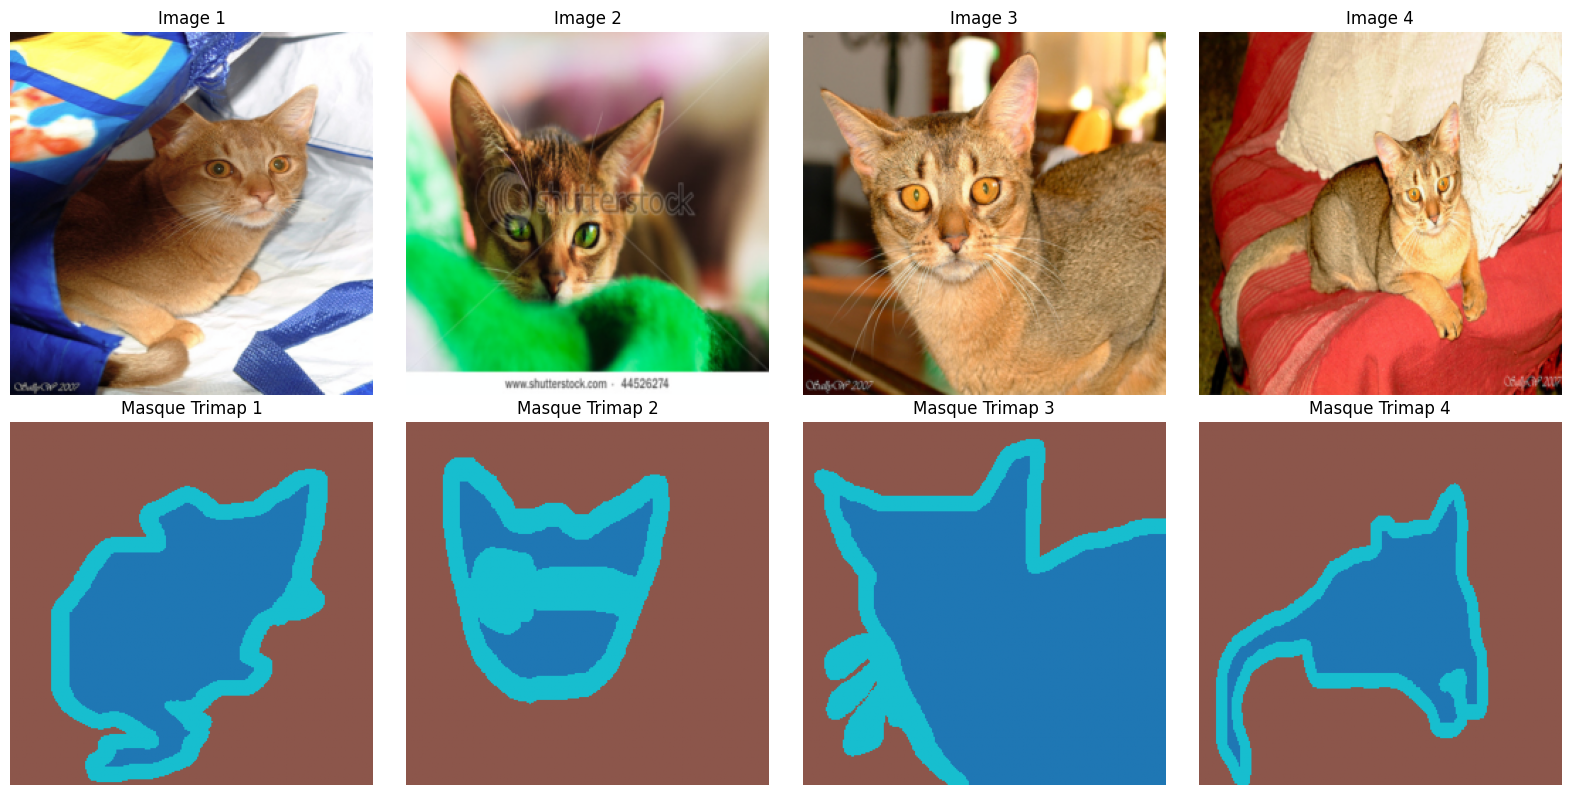

In [1]:
# %% [markdown]
# ### Exercice 1 - Partie 1 : Préparation du Dataset et Exploration (Version Google Colab)

# %%
import torch
import torchvision
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.datasets as datasets
from PIL import Image

# Configuration des seeds pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# --- 1. CONFIGURATION ET TÉLÉCHARGEMENT AUTOMATIQUE ---
# Sur Colab, on télécharge le dataset officiel directement via torchvision dans /content/data
DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

print(" Téléchargement et extraction du dataset Oxford-IIIT Pet...")
# On force le téléchargement automatique des images et des masques de segmentation (target_types='segmentation')
_ = datasets.OxfordIIITPet(root=DATA_ROOT, target_types='segmentation', download=True)
print("Dataset prêt et structuré dans /content/data !")

# --- 2. CLASSE DATASET ADAPTÉE POUR COLAB ---
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=256, transform=None):
        # Torchvision télécharge les données dans un sous-dossier fixe 'oxford-iiit-pet'
        self.root = os.path.join(root, 'oxford-iiit-pet')
        self.split = split
        self.img_size = img_size
        self.transform = transform

        # Transformations de base obligatoires
        self.base_img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        self.base_mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST)
        ])

        # Lecture du fichier de split texte officiel
        list_file = os.path.join(self.root, 'annotations', 'trainval.txt' if split == 'train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'images', self.names[idx] + '.jpg')
        # Les masques s'appellent des trimaps dans ce dataset
        mask_path = os.path.join(self.root, 'annotations', 'trimaps', self.names[idx] + '.png')

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        # Application de l'augmentation de données conjointe si définie
        if self.transform:
            img, mask = self.transform(img, mask)

        img_t = self.base_img_transform(img)
        mask_np = np.array(self.base_mask_transform(mask))

        #  CRUCIAL : Les trimaps d'Oxford ont pour valeurs de pixels 1, 2, 3.
        # On fait -1 pour avoir 0, 1, 2 (requis pour la CrossEntropyLoss de PyTorch)
        mask_np = mask_np - 1
        mask_t = torch.tensor(mask_np, dtype=torch.long)

        return img_t, mask_t

# --- 3. PIPELINE DE CALCUL DES STATISTIQUES (Q1) ---
full_dataset = PetSegmentationDataset(root=DATA_ROOT, split='train')
print(f"\nNombre total d'images chargées pour l'entraînement/validation : {len(full_dataset)}")

print("\nCalcul de la distribution réelle des pixels à partir de 200 masques...")
class_counts = np.zeros(3)
sample_indices = np.random.choice(len(full_dataset), min(200, len(full_dataset)), replace=False)

for idx in sample_indices:
    _, mask = full_dataset[idx]
    for c in range(3):
        class_counts[c] += (mask == c).sum().item()

total_pixels = class_counts.sum()
class_percentages = (class_counts / total_pixels) * 100
class_names = ['0: Intérieur/Animal', '1: Extérieur/Fond', '2: Contour']

print("\n===  DISTRIBUTION DES CLASSES (Q1) ===")
for name, pct in zip(class_names, class_percentages):
    print(f"Classe {name} : {pct:.2f}% des pixels")

# --- 4. AFFICHAGE DE LA VISUALISATION CÔTE À CÔTE ---
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_t, mask_t = full_dataset[i]

    # Dé-normalisation de l'image pour affichage standard RGB
    img_disp = img_t.permute(1, 2, 0).numpy()
    img_disp = img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_disp = np.clip(img_disp, 0, 1)

    axs[0, i].imshow(img_disp)
    axs[0, i].set_title(f"Image {i+1}")
    axs[0, i].axis('off')

    # Masque coloré (0=animal, 1=fond, 2=contour)
    axs[1, i].imshow(mask_t.numpy(), cmap='tab10')
    axs[1, i].set_title(f"Masque Trimap {i+1}")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

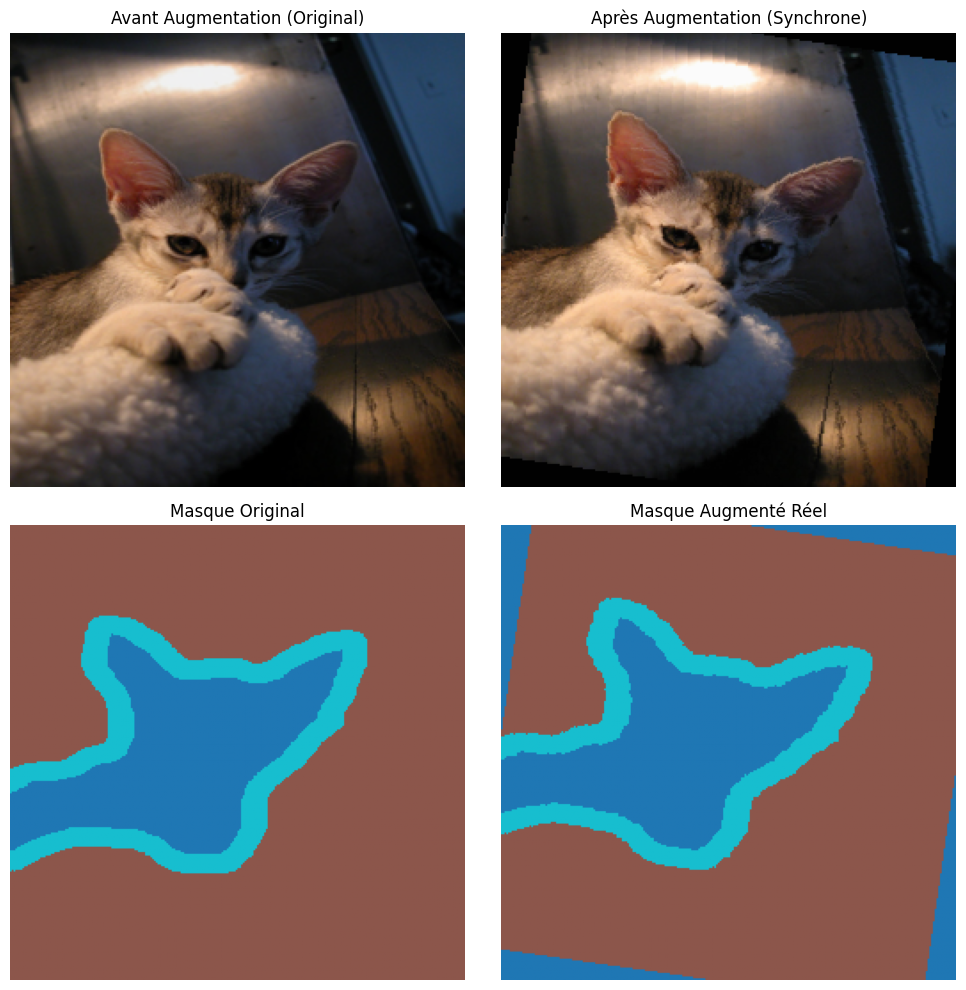

In [8]:
# %% [markdown]
# ### Version Corrigée Globale : Dataset + Augmentation Synchrone Directe

# %%
import torch
import torchvision
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.datasets as datasets
from PIL import Image

# Configuration des seeds pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DATA_ROOT = "./data"

# --- CLASSE DATASET COMPLÈTE AVEC AUGMENTATION INTÉGRÉE (SANS BUG PIL) ---
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=256, augment=False):
        self.root = os.path.join(root, 'oxford-iiit-pet')
        self.split = split
        self.img_size = img_size
        self.augment = augment  # Activer ou non l'augmentation géométrique

        # Redimensionnement de base obligatoire
        self.img_resize = transforms.Resize((img_size, img_size))
        self.mask_resize = transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST)

        # Normalisation standard ImageNet
        self.img_normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        # Lecture du fichier de split officiel
        list_file = os.path.join(self.root, 'annotations', 'trainval.txt' if split == 'train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'images', self.names[idx] + '.jpg')
        mask_path = os.path.join(self.root, 'annotations', 'trimaps', self.names[idx] + '.png')

        # 1. Chargement initial en PIL et redimensionnement immédiat
        img = self.img_resize(Image.open(img_path).convert('RGB'))
        mask = self.mask_resize(Image.open(mask_path))

        # 2. Conversion immédiate en Tenseurs PyTorch
        img_t = transforms.functional.to_tensor(img)  # Shape: (3, H, W), valeurs: [0.0, 1.0]

        mask_np = np.array(mask) - 1  # Remappage crucial [1, 2, 3] -> [0, 1, 2]
        mask_t = torch.tensor(mask_np, dtype=torch.long).unsqueeze(0)  # Shape: (1, H, W)

        # 3. Application de l'augmentation synchrone purement sous PyTorch (Q2)
        if self.augment:
            # Flips horizontaux (50% de chance)
            if random.random() > 0.5:
                img_t = transforms.functional.horizontal_flip(img_t)
                mask_t = transforms.functional.horizontal_flip(mask_t)

            # Rotation aléatoire synchrone (-10 à 10 degrés)
            angle = random.uniform(-10, 10)
            img_t = transforms.functional.rotate(img_t, angle)
            # Utilisation stricte du mode NEAREST pour ne pas interpoler les indices de classes (0, 1, 2)
            mask_t = transforms.functional.rotate(mask_t, angle, interpolation=transforms.InterpolationMode.NEAREST)

            # Color Jitter appliqué UNIQUEMENT sur l'image
            color_jitter = transforms.ColorJitter(brightness=0.1, contrast=0.1)
            img_t = color_jitter(img_t)

        # 4. Normalisation finale de l'image (à faire obligatoirement APRES l'augmentation)
        img_t = self.img_normalize(img_t)
        mask_t = mask_t.squeeze(0)  # Shape finale: (H, W)

        return img_t, mask_t

# --- CODE DE VÉRIFICATION AVANT / APRÈS ---
# Instanciation de deux datasets sur le même split pour comparer l'index 10
dataset_brut = PetSegmentationDataset(root=DATA_ROOT, split='train', augment=False)
dataset_augm = PetSegmentationDataset(root=DATA_ROOT, split='train', augment=True)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Affichage Original (Avant)
img_b, m_b = dataset_brut[10]
img_disp_b = img_b.permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
axs[0, 0].imshow(np.clip(img_disp_b, 0, 1))
axs[0, 0].set_title("Avant Augmentation (Original)")
axs[0, 0].axis('off')

axs[1, 0].imshow(m_b.numpy(), cmap='tab10')
axs[1, 0].set_title("Masque Original")
axs[1, 0].axis('off')

# Affichage avec Augmentation Tenseur pure (Après)
random.seed(123)  # On fixe la seed pour voir la rotation s'appliquer
img_a, m_a = dataset_augm[10]
img_disp_a = img_a.permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
axs[0, 1].imshow(np.clip(img_disp_a, 0, 1))
axs[0, 1].set_title("Après Augmentation (Synchrone)")
axs[0, 1].axis('off')

axs[1, 1].imshow(m_a.numpy(), cmap='tab10')
axs[1, 1].set_title("Masque Augmenté Réel")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# %% [markdown]
# ### Exercice 1 - Partie 1 - Question 3 : Partition 70/15/15 et DataLoaders CORRIGÉE

# %%
from torch.utils.data import random_split

# 1. Récupération de l'ensemble de test officiel (sans augmentation géométrique)
dataset_total_test = PetSegmentationDataset(root=DATA_ROOT, split='test', augment=False)

# 2. Récupération de l'ensemble d'entraînement complet (avec l'augmentation activée via augment=True)
dataset_total_train = PetSegmentationDataset(root=DATA_ROOT, split='train', augment=True)

# 3. Combinaison des deux blocs pour appliquer le découpage global exigé par le TP (70/15/15)
dataset_combined = torch.utils.data.ConcatDataset([dataset_total_train, dataset_total_test])

total_samples = len(dataset_combined)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# Split rigoureux avec seed fixe pour la reproductibilité
train_dataset, val_dataset, test_dataset = random_split(
    dataset_combined, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Taille de batch optimisée pour la VRAM du GPU T4 de Colab (Justification Q3)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("=== CONFIGURATION DES DATALOADERS TERMINÉE (Q3) ===")
print(f"Nombre total d'images dans le projet : {total_samples}")
print(f"Train Set      : {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"Validation Set : {len(val_dataset)} images ({len(val_loader)} batches)")
print(f"Test Set       : {len(test_dataset)} images ({len(test_loader)} batches)")

=== CONFIGURATION DES DATALOADERS TERMINÉE (Q3) ===
Nombre total d'images dans le projet : 7349
Train Set      : 5144 images (160 batches)
Validation Set : 1102 images (35 batches)
Test Set       : 1103 images (35 batches)


In [11]:
# %% [markdown]
# ### Exercice 1 - Partie 2 - Question 4 : Instanciation et Analyse de SimpleUNet

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F

# Installation propre de torchinfo pour Google Colab s'il n'est pas déjà présent
!pip install torchinfo -q
from torchinfo import summary

# --- 1. DOUBLE CONVOLUTION BLOCK ---
class ConvBlock(nn.Module):
    """Double convolution : Conv2d -> BN -> ReLU -> Conv2d -> BN -> ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

# --- 2. ARCHITECTURE SIMPLE UNET ---
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, base_features=32):
        super().__init__()
        f = base_features
        self.pool = nn.MaxPool2d(2)

        # --- ENCODEUR ---
        self.enc1 = ConvBlock(in_channels, f)     # 256x256 -> 256x256
        self.enc2 = ConvBlock(f, f*2)             # 128x128 -> 128x128
        self.enc3 = ConvBlock(f*2, f*4)           # 64x64   -> 64x64
        self.enc4 = ConvBlock(f*4, f*8)           # 32x32   -> 32x32

        # --- BOTTLENECK ---
        self.bottleneck = ConvBlock(f*8, f*16)    # 16x16   -> 16x16

        # --- DÉCODEUR ---
        self.up4 = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)          # f*8 (up) + f*8 (skip enc4) = f*16

        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = ConvBlock(f*8, f*4)           # f*4 (up) + f*4 (skip enc3) = f*8

        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = ConvBlock(f*4, f*2)           # f*2 (up) + f*2 (skip enc2) = f*4

        self.up1 = nn.ConvTranspose2d(f*2, f, 2, stride=2)
        self.dec1 = ConvBlock(f*2, f)             # f (up) + f (skip enc1) = f*2

        self.out_conv = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        # Encodage + skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b  = self.bottleneck(self.pool(e4))

        # Décodage avec concaténation des skip connections (dim=1 pour les canaux)
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)

# --- 3. INSTANCIATION ET AFFICHAGE DU RÉSUMÉ DETRAILLÉ ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_unet = SimpleUNet(in_channels=3, num_classes=3, base_features=32).to(device)

print("\n=== STRUCTURE INTERNE ET DIMENSIONS DES TENSEURS ===")
# On affiche le résumé d'architecture en simulant l'envoi d'un lot correspondant à notre BATCH_SIZE (32)
summary(model_unet, input_size=(32, 3, 256, 256), device=device.type)


=== STRUCTURE INTERNE ET DIMENSIONS DES TENSEURS ===


Layer (type:depth-idx)                   Output Shape              Param #
SimpleUNet                               [32, 3, 256, 256]         --
├─ConvBlock: 1-1                         [32, 32, 256, 256]        --
│    └─Sequential: 2-1                   [32, 32, 256, 256]        --
│    │    └─Conv2d: 3-1                  [32, 32, 256, 256]        864
│    │    └─BatchNorm2d: 3-2             [32, 32, 256, 256]        64
│    │    └─ReLU: 3-3                    [32, 32, 256, 256]        --
│    │    └─Conv2d: 3-4                  [32, 32, 256, 256]        9,216
│    │    └─BatchNorm2d: 3-5             [32, 32, 256, 256]        64
│    │    └─ReLU: 3-6                    [32, 32, 256, 256]        --
├─MaxPool2d: 1-2                         [32, 32, 128, 128]        --
├─ConvBlock: 1-3                         [32, 64, 128, 128]        --
│    └─Sequential: 2-2                   [32, 64, 128, 128]        --
│    │    └─Conv2d: 3-7                  [32, 64, 128, 128]        18,432
│    │ 

🚀 Lancement de la boucle d'entraînement sur CUDA...
--------------------------------------------------


Epoch 1/30 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [ 1/30] | Train Loss: 0.6201 | Val Loss: 0.5201 | Temps: 114.1s
   -> 💾 Checkpoint mis à jour et sauvegardé !


Epoch 2/30 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [29/30] | Train Loss: 0.1599 | Val Loss: 0.2501 | Temps: 113.2s


Epoch 30/30 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [30/30] | Train Loss: 0.1577 | Val Loss: 0.2391 | Temps: 113.0s


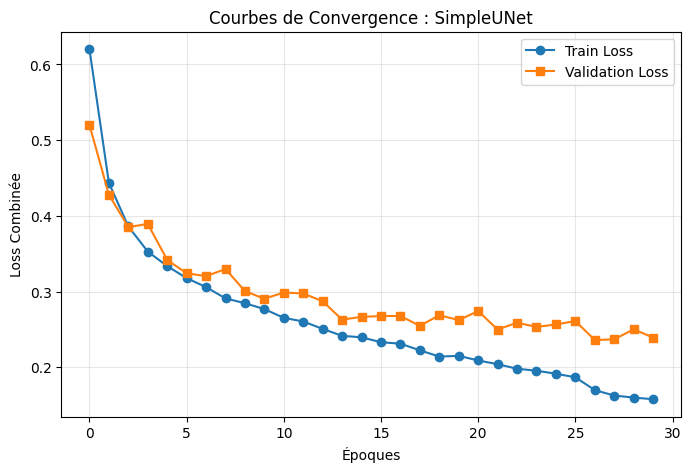

In [17]:
# %% [markdown]
# ### Exercice 1 - Partie 2 - Question 6 : Entraînement SimpleUNet (Version Unifiée Ultra-Robuste)

# %%
import torch.optim as optim
import time
from tqdm.notebook import tqdm

# --- 1. FONCTION DICE LOSS INCORPORÉE (Q5) ---
def dice_loss(pred, target, num_classes=3, smooth=1e-6):
    pred_softmax = F.softmax(pred, dim=1)
    dice = 0
    for cls in range(num_classes):
        pred_cls = pred_softmax[:, cls]
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += 1 - (2 * intersection + smooth) / (union + smooth)
    return dice / num_classes

# --- 2. LOGIQUE DE LA PERTE COMBINÉE ---
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, weight=None):
        super().__init__()
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, pred, target):
        loss_ce = self.ce(pred, target)
        loss_dice = dice_loss(pred, target)
        return self.alpha * loss_ce + (1.0 - self.alpha) * loss_dice

# --- 3. CONFIGURATION DES OBJETS D'ENTRAÎNEMENT ---
# Poids de la Q1 pour rééquilibrer le dataset
weights_classes = torch.tensor([3.20, 1.76, 8.40]).to(device)

criterion = CombinedLoss(alpha=0.5, weight=weights_classes)
optimizer = optim.Adam(model_unet.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Hyperparamètres de contrôle
epochs = 30
patience_early_stopping = 5
best_val_loss = float('inf')
no_improvement_epochs = 0

history = {'train_loss': [], 'val_loss': []}

print(f"Lancement de la boucle d'entraînement sur {device.type.upper()}...")
print("-" * 50)

# --- 4. BOUCLE PRINCIPALE ---
for epoch in range(epochs):
    t0 = time.time()

    # Phase d'entraînement
    model_unet.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model_unet(imgs)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    epoch_train_loss = train_loss / len(train_loader.dataset)

    # Phase de validation
    model_unet.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model_unet(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * imgs.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)

    # Évolution du Learning Rate si plateau détecté
    scheduler.step(epoch_val_loss)

    # Archivage pour les graphiques
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Temps: {elapsed:.1f}s")

    # Early Stopping & Checkpoint (Q6)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model_unet.state_dict(), 'best_unet.pth')
        print("   ->  Checkpoint mis à jour et sauvegardé !")
        no_improvement_epochs = 0
    else:
        no_improvement_epochs += 1

    if no_improvement_epochs >= patience_early_stopping:
        print(f"\n🛑 Arrêt anticipé activé (Early Stopping) à l'époque {epoch+1} !")
        break

# --- 5. VISUALISATION DES COURBES DE LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Époques')
plt.ylabel('Loss Combinée')
plt.title('Courbes de Convergence : SimpleUNet')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('unet_convergence.png', dpi=120)
plt.show()

Dans les versions les plus récentes de PyTorch (que Google Colab met à jour automatiquement), la fonction horizontal_flip a été déplacée ou renommée en hflip dans torchvision.transforms.functional. C'est pour cela qu'il lève une erreur AttributeError.

On va corriger ça en modifiant la classe PetSegmentationDataset pour utiliser hflip à la place, et tout rentrera dans l'ordre.

#La solution :On ré-exécute ce bloc pour corriger la définition du Dataset et des DataLoaders
Pour que ton notebook Colab soit totalement à jour sans erreur, ré-exécute cette cellule unique pour redéfinir proprement ton dataset avec hflip et recréer les DataLoaders :

In [14]:
# %% [markdown]
# ### Version Unifiée et Corrigée : Dataset avec transforms.functional.hflip

# %%
import torch
import torchvision
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.datasets as datasets
from PIL import Image

# Configuration des seeds pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DATA_ROOT = "./data"

# --- CLASSE DATASET MAILLÉE SANS ATTRIBUTE_ERROR ---
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=256, augment=False):
        self.root = os.path.join(root, 'oxford-iiit-pet')
        self.split = split
        self.img_size = img_size
        self.augment = augment

        self.img_resize = transforms.Resize((img_size, img_size))
        self.mask_resize = transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST)
        self.img_normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        list_file = os.path.join(self.root, 'annotations', 'trainval.txt' if split == 'train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'images', self.names[idx] + '.jpg')
        mask_path = os.path.join(self.root, 'annotations', 'trimaps', self.names[idx] + '.png')

        img = self.img_resize(Image.open(img_path).convert('RGB'))
        mask = self.mask_resize(Image.open(mask_path))

        img_t = transforms.functional.to_tensor(img)
        mask_np = np.array(mask) - 1
        mask_t = torch.tensor(mask_np, dtype=torch.long).unsqueeze(0)

        if self.augment:
            # Correction cruciale : hflip au lieu de horizontal_flip
            if random.random() > 0.5:
                img_t = transforms.functional.hflip(img_t)
                mask_t = transforms.functional.hflip(mask_t)

            angle = random.uniform(-10, 10)
            img_t = transforms.functional.rotate(img_t, angle)
            mask_t = transforms.functional.rotate(mask_t, angle, interpolation=transforms.InterpolationMode.NEAREST)

            color_jitter = transforms.ColorJitter(brightness=0.1, contrast=0.1)
            img_t = color_jitter(img_t)

        img_t = self.img_normalize(img_t)
        mask_t = mask_t.squeeze(0)

        return img_t, mask_t

# --- RE-PARTITION ET DATALOADERS ---
dataset_total_test = PetSegmentationDataset(root=DATA_ROOT, split='test', augment=False)
dataset_total_train = PetSegmentationDataset(root=DATA_ROOT, split='train', augment=True)
dataset_combined = torch.utils.data.ConcatDataset([dataset_total_train, dataset_total_test])

total_samples = len(dataset_combined)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset_combined, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✅ Dataset et DataLoaders mis à jour avec succès !")

✅ Dataset et DataLoaders mis à jour avec succès !


Evaluating SimpleUNet on the test dataset...

================ METRIQUES SUR L'ENSEMBLE DE TEST ================
Mean IoU (mIoU)   : 0.7765
Mean Dice Score   : 0.8662

Classe 0 (Animal)   | IoU: 0.8488 | Dice: 0.9182
Classe 1 (Fond)     | IoU: 0.9065 | Dice: 0.9510
Classe 2 (Contour)  | IoU: 0.5742 | Dice: 0.7295


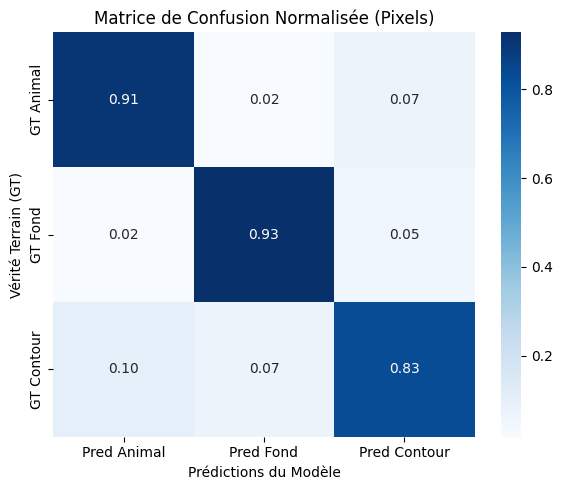

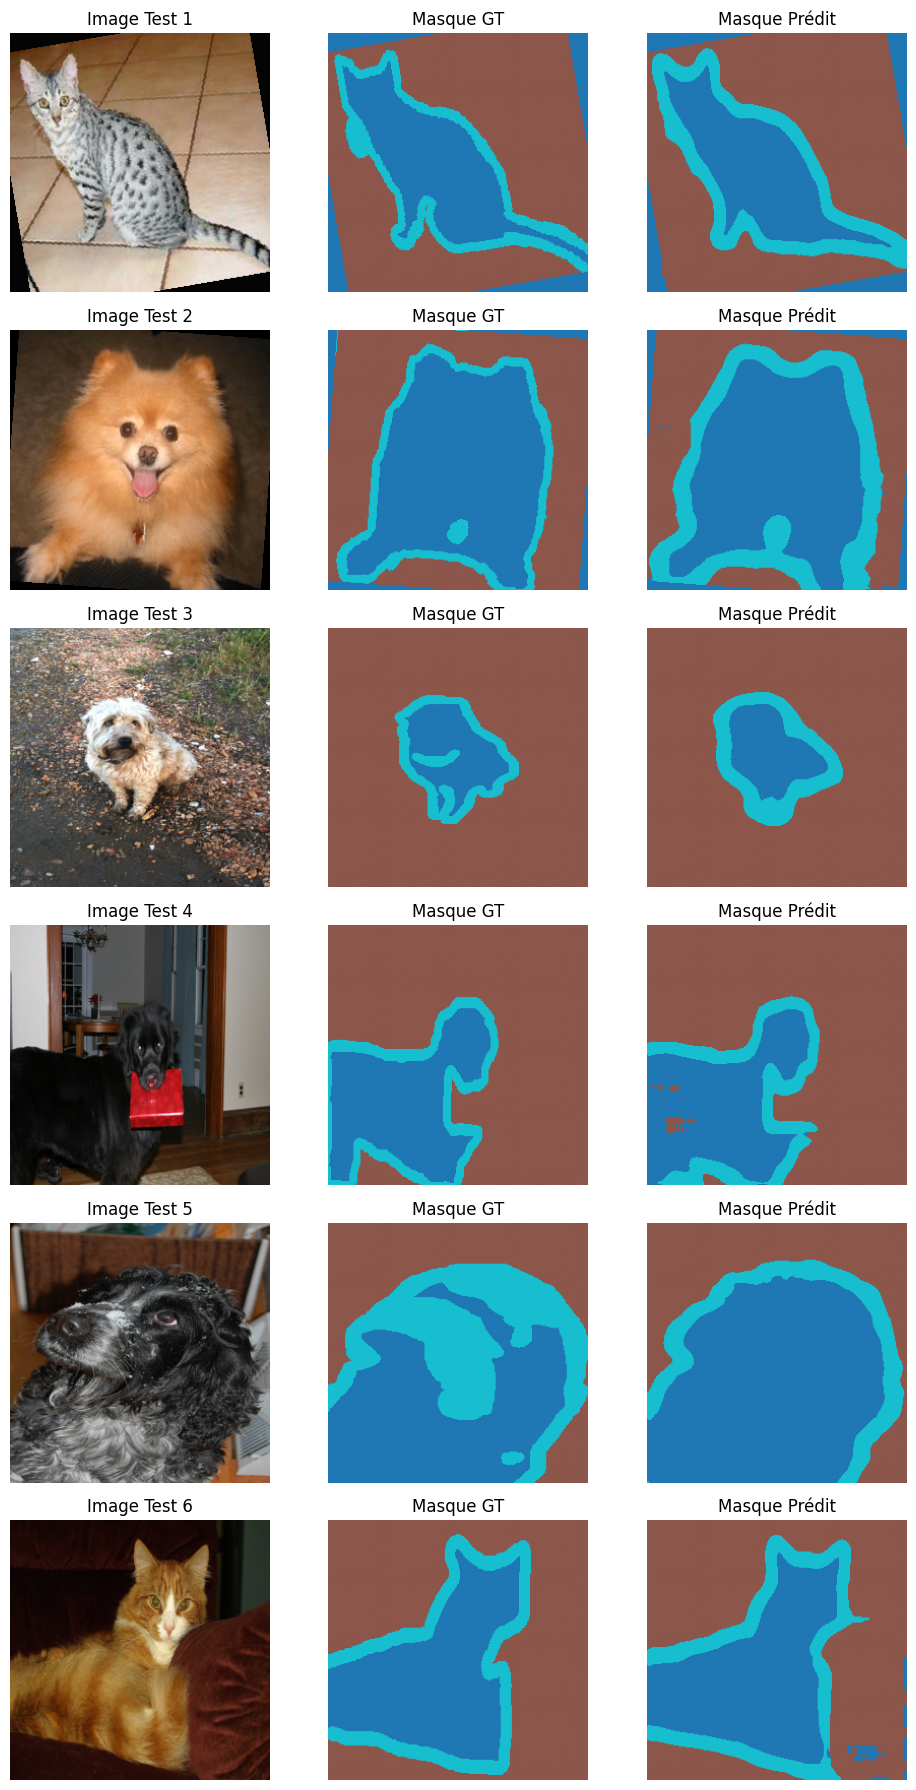

In [18]:
# %% [markdown]
# ### Exercice 1 - Partie 2 - Question 7 : Évaluation complète sur le Test Set

# %%
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- 1. FONCTION DE CALCUL IOU & DICE (Métriques demandées) ---
def compute_iou_dice(pred_mask, true_mask, num_classes=3):
    """
    Calcule le mIoU et le mDice cumulatifs pixel par pixel pour un batch ou un dataset
    """
    iou_per_class = np.zeros(num_classes)
    dice_per_class = np.zeros(num_classes)

    pred_flat = pred_mask.flatten()
    true_flat = true_mask.flatten()

    for cls in range(num_classes):
        intersection = np.sum((pred_flat == cls) & (true_flat == cls))
        union = np.sum((pred_flat == cls) | (true_flat == cls))
        target_sum = np.sum(true_flat == cls)
        pred_sum = np.sum(pred_flat == cls)

        # Calcul de l'IoU (Jaccard)
        if union == 0:
            iou_per_class[cls] = 1.0  # Si la classe est absente partout, l'accord est parfait
        else:
            iou_per_class[cls] = intersection / union

        # Calcul du Dice Score (F1-score spatial)
        if (target_sum + pred_sum) == 0:
            dice_per_class[cls] = 1.0
        else:
            dice_per_class[cls] = (2. * intersection) / (target_sum + pred_sum)

    mIoU = np.mean(iou_per_class)
    mDice = np.mean(dice_per_class)

    return mIoU, mDice, iou_per_class, dice_per_class

# --- 2. CHARGEMENT DES MEILLEURS POIDS DU RÉSEAU ---
model_unet.load_state_dict(torch.load('best_unet.pth', map_location=device))
model_unet.eval()

all_preds = []
all_targets = []
visual_examples = []

# Extraction d'échantillons du Test Loader
print("Evaluating SimpleUNet on the test dataset...")
with torch.no_grad():
    for i, (imgs, masks) in enumerate(test_loader):
        imgs = imgs.to(device)
        outputs = model_unet(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        masks_np = masks.numpy()

        all_preds.append(preds)
        all_targets.append(masks_np)

        # On sauvegarde quelques exemples pour le tracé visuel final (Q7-c)
        if len(visual_examples) < 6:
            for b in range(imgs.size(0)):
                if len(visual_examples) < 6:
                    visual_examples.append({
                        'img': imgs[b].cpu(),
                        'gt': masks_np[b],
                        'pred': preds[b]
                    })

# Reconstitution globale sous forme de gros vecteurs numpy
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# --- 3. CALCUL DES SCORES FINAUX ---
mIoU, mDice, iou_per_class, dice_per_class = compute_iou_dice(all_preds, all_targets, num_classes=3)

print("\n================ METRIQUES SUR L'ENSEMBLE DE TEST ================")
print(f"Mean IoU (mIoU)   : {mIoU:.4f}")
print(f"Mean Dice Score   : {mDice:.4f}\n")
classes_labels = ["0 (Animal)", "1 (Fond)", "2 (Contour)"]
for idx, label in enumerate(classes_labels):
    print(f"Classe {label:12s} | IoU: {iou_per_class[idx]:.4f} | Dice: {dice_per_class[idx]:.4f}")
print("==================================================================")

# --- 4. AFFICHAGE DE LA MATRICE DE CONFUSION (Q7-a) ---
cm = confusion_matrix(all_targets.flatten(), all_preds.flatten())
# Normalisation par ligne pour obtenir des pourcentages de précision par classe
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Pred Animal", "Pred Fond", "Pred Contour"],
            yticklabels=["GT Animal", "GT Fond", "GT Contour"])
plt.title("Matrice de Confusion Normalisée (Pixels)")
plt.ylabel('Vérité Terrain (GT)')
plt.xlabel('Prédictions du Modèle')
plt.tight_layout()
plt.show()

# --- 5. AFFICHAGE DES 6 EXEMPLES COMPARATIFS (Q7-c) ---
fig, axs = plt.subplots(6, 3, figsize=(10, 18))
for idx, ex in enumerate(visual_examples):
    # Dé-normalisation de l'image originale
    img_disp = ex['img'].permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_disp = np.clip(img_disp, 0, 1)

    axs[idx, 0].imshow(img_disp)
    axs[idx, 0].set_title(f"Image Test {idx+1}")
    axs[idx, 0].axis('off')

    axs[idx, 1].imshow(ex['gt'], cmap='tab10')
    axs[idx, 1].set_title("Masque GT")
    axs[idx, 1].axis('off')

    axs[idx, 2].imshow(ex['pred'], cmap='tab10')
    axs[idx, 2].set_title("Masque Prédit")
    axs[idx, 2].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# %% [markdown]
# ### Exercice 1 - Partie 3 - Question 8 : Architecture TransferUNet Complète

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from torchinfo import summary

# On s'assure d'utiliser le ConvBlock défini dans la Partie 2
# (S'il est déjà en mémoire, cette classe est une réplique exacte)
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

# --- ARCHITECTURE TRANSFER UNET CORRIGÉE & COMPLÈTE (Q8) ---
class TransferUNet(nn.Module):
    def __init__(self, num_classes=3, freeze_encoder=True):
        super().__init__()
        # Chargement du squelette ResNet50 pré-entraîné sur ImageNet
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # --- Extraction des couches de l'encodeur ---
        self.enc0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )                                                  # Réduction /2  -> 64 canaux
        self.pool = backbone.maxpool                       # Réduction /4  -> 64 canaux
        self.enc1 = backbone.layer1                        # Réduction /4  -> 256 canaux
        self.enc2 = backbone.layer2                        # Réduction /8  -> 512 canaux
        self.enc3 = backbone.layer3                        # Réduction /16 -> 1024 canaux
        self.enc4 = backbone.layer4                        # Réduction /32 -> 2048 canaux

        # Gel optionnel des paramètres de l'encodeur (Q9-a)
        if freeze_encoder:
            for param in [self.enc0, self.enc1, self.enc2, self.enc3, self.enc4]:
                for p in param.parameters():
                    p.requires_grad = False

        # --- Décodeur (Ajusté mathématiquement pour éviter les crashs de concaténation) ---
        self.up4 = nn.ConvTranspose2d(2048, 1024, 2, stride=2)
        self.dec4 = ConvBlock(2048, 512)  # up4(1024) + enc3(1024) = 2048 canaux

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(768, 256)   # up3(256) + enc2(512) = 768 canaux (Corrigé !)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(384, 64)    # up2(128) + enc1(256) = 384 canaux (Corrigé !)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(96, 32)     # up1(32) + enc0(64) = 96 canaux

        # Remontée finale à l'échelle spatiale originale (128x128 -> 256x256)
        self.final_up = nn.ConvTranspose2d(32, 32, 2, stride=2)
        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        # --- Phase d'encodage ResNet ---
        e0 = self.enc0(x)                 # Shape: [B, 64, 128, 128]
        e1 = self.enc1(self.pool(e0))     # Shape: [B, 256, 64, 64]
        e2 = self.enc2(e1)                # Shape: [B, 512, 32, 32]
        e3 = self.enc3(e2)                # Shape: [B, 1024, 16, 16]
        e4 = self.enc4(e3)                # Shape: [B, 2048, 8, 8] (Bottleneck profond)

        # --- Phase de décodage avec Skip Connections ---
        d4 = self.dec4(torch.cat([self.up4(e4), e3], dim=1))  # [B, 512, 16, 16]
        d3 = self.dec3(torch.cat([self.up3(d4), e2], dim=1))  # [B, 256, 32, 32]
        d2 = self.dec2(torch.cat([self.up2(d3), e1], dim=1))  # [B, 64, 64, 64]
        d1 = self.dec1(torch.cat([self.up1(d2), e0], dim=1))  # [B, 32, 128, 128]

        # Résolution finale originale 256x256
        out_spatial = self.final_up(d1)                       # [B, 32, 256, 256]
        return self.out(out_spatial)                          # [B, 3, 256, 256]

# --- VÉRIFICATION PAR PASSAGE FICTIF ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_transfer = TransferUNet(num_classes=3, freeze_encoder=True).to(device)

print("=== Architecture Détaillée du TransferUNet ===")
summary(model_transfer, input_size=(32, 3, 256, 256), device=device.type)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.8MB/s]


=== Architecture Détaillée du TransferUNet ===


Layer (type:depth-idx)                   Output Shape              Param #
TransferUNet                             [32, 3, 256, 256]         --
├─Sequential: 1-1                        [32, 64, 128, 128]        --
│    └─Conv2d: 2-1                       [32, 64, 128, 128]        (9,408)
│    └─BatchNorm2d: 2-2                  [32, 64, 128, 128]        (128)
│    └─ReLU: 2-3                         [32, 64, 128, 128]        --
├─MaxPool2d: 1-2                         [32, 64, 64, 64]          --
├─Sequential: 1-3                        [32, 256, 64, 64]         --
│    └─Bottleneck: 2-4                   [32, 256, 64, 64]         --
│    │    └─Conv2d: 3-1                  [32, 64, 64, 64]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 64, 64]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 64, 64]          --
│    │    └─Conv2d: 3-4                  [32, 64, 64, 64]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 64, 64]      

🔄 Initialisation de la Stratégie A (Encoder Frozen)...

🎬 Début de l'apprentissage : TransferUNet Frozen


TransferUNet Frozen | Epoch 1/15 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

TransferUNet Frozen | Epoch 1/15 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [ 1/15] | Train Loss: 0.3540 | Val Loss: 0.2288 | Temps: 83.6s


TransferUNet Frozen | Epoch 2/15 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

...

TransferUNet Fine-Tuned | Epoch 14/15 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.1352 | Val Loss: 0.2025 | Temps: 118.3s


TransferUNet Fine-Tuned | Epoch 15/15 [Train]:   0%|          | 0/160 [00:00<?, ?it/s]

TransferUNet Fine-Tuned | Epoch 15/15 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.1316 | Val Loss: 0.1907 | Temps: 118.2s


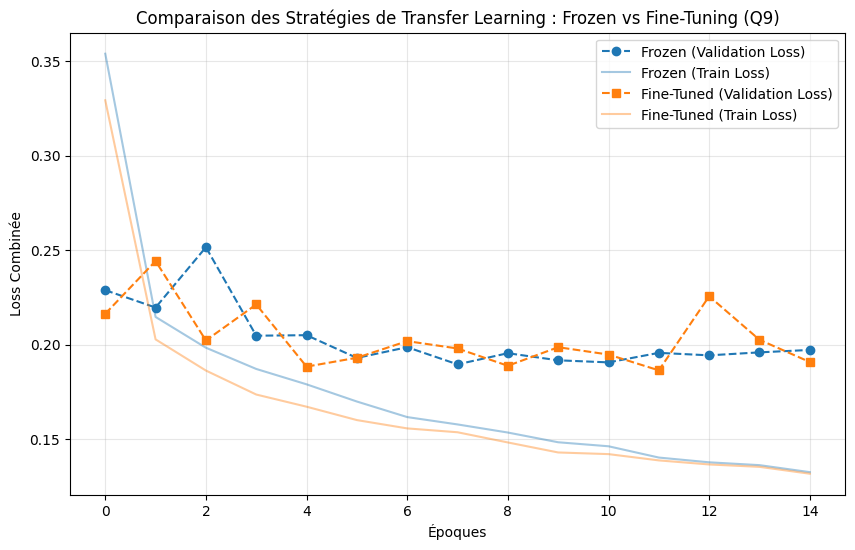

In [20]:
# %% [markdown]
# ### Exercice 1 - Partie 3 - Question 9 : Entraînement Comparatif (Frozen vs Fine-Tuning)

# %%
import torch.optim as optim
import time
import copy
from tqdm.notebook import tqdm

# On s'assure d'utiliser la fonction de perte combinée stable du projet
weights_classes = torch.tensor([3.20, 1.76, 8.40]).to(device)
criterion = CombinedLoss(alpha=0.5, weight=weights_classes)

# Fonction générique pour entraîner nos deux configurations sans dupliquer le code
def train_transfer_model(model_instance, optimizer_instance, name, epochs_limit=15):
    history_log = {'train_loss': [], 'val_loss': []}
    best_loss = float('inf')

    print(f"\n🎬 Début de l'apprentissage : {name}")
    print("=" * 60)

    for epoch in range(epochs_limit):
        t0 = time.time()

        # --- PHASE ENTRAÎNEMENT ---
        model_instance.train()
        train_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f"{name} | Epoch {epoch+1}/{epochs_limit} [Train]", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer_instance.zero_grad()
            outputs = model_instance(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer_instance.step()
            train_loss += loss.item() * imgs.size(0)
        epoch_train_loss = train_loss / len(train_loader.dataset)

        # --- PHASE VALIDATION ---
        model_instance.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f"{name} | Epoch {epoch+1}/{epochs_limit} [Val]", leave=False):
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model_instance(imgs)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * imgs.size(0)
        epoch_val_loss = val_loss / len(val_loader.dataset)

        history_log['train_loss'].append(epoch_train_loss)
        history_log['val_loss'].append(epoch_val_loss)

        elapsed = time.time() - t0
        print(f"Epoch [{epoch+1:2d}/{epochs_limit}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Temps: {elapsed:.1f}s")

        # Sauvegarde du meilleur état sur le disque
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            torch.save(model_instance.state_dict(), f'best_transfer_{name.lower().replace(" ", "_")}.pth')

    return history_log

# =========================================================================
# STRATÉGIE A : ENCODEUR GELÉ (FROZEN)
# =========================================================================
print(" Initialisation de la Stratégie A (Encoder Frozen)...")
model_frozen = TransferUNet(num_classes=3, freeze_encoder=True).to(device)

# Seuls les paramètres requis par le gradient (le décodeur) sont passés à l'optimiseur
optimizer_frozen = optim.Adam(filter(lambda p: p.requires_grad, model_frozen.parameters()), lr=1e-3)
history_frozen = train_transfer_model(model_frozen, optimizer_frozen, "TransferUNet Frozen", epochs_limit=15)

# =========================================================================
# STRATÉGIE B : FINE-TUNING COMPLET AVEC LEARNING RATE DIFFÉRENTIEL
# =========================================================================
print("\n Initialisation de la Stratégie B (Fine-Tuning Différentiel)...")
model_ft = TransferUNet(num_classes=3, freeze_encoder=False).to(device)

# Définition des groupes de paramètres avec des taux d'apprentissage distincts (Q9-b)
encoder_params = []
decoder_params = []

# Séparation chirurgicale des couches basées sur leur nommage
for name, param in model_ft.named_parameters():
    if any(enc_name in name for enc_name in ['enc0', 'enc1', 'enc2', 'enc3', 'enc4']):
        encoder_params.append(param)
    else:
        decoder_params.append(param)

optimizer_ft = optim.Adam([
    {'params': encoder_params, 'lr': 1e-4, 'weight_decay': 1e-4},  # Pas très fin pour l'encodeur
    {'params': decoder_params, 'lr': 1e-3, 'weight_decay': 1e-4}   # Pas standard pour le décodeur
])

history_ft = train_transfer_model(model_ft, optimizer_ft, "TransferUNet Fine-Tuned", epochs_limit=15)

# =========================================================================
#  TRACÉ DU GRAPHIQUE DE CONVERGENCE COMPARATIF (Q9)
# =========================================================================
plt.figure(figsize=(10, 6))

plt.plot(history_frozen['val_loss'], label='Frozen (Validation Loss)', color='tab:blue', linestyle='--', marker='o')
plt.plot(history_frozen['train_loss'], label='Frozen (Train Loss)', color='tab:blue', alpha=0.4)

plt.plot(history_ft['val_loss'], label='Fine-Tuned (Validation Loss)', color='tab:orange', linestyle='--', marker='s')
plt.plot(history_ft['train_loss'], label='Fine-Tuned (Train Loss)', color='tab:orange', alpha=0.4)

plt.xlabel('Époques')
plt.ylabel('Loss Combinée')
plt.title('Comparaison des Stratégies de Transfer Learning : Frozen vs Fine-Tuning (Q9)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('transfer_learning_convergence.png', dpi=120)
plt.show()

In [21]:
# %% [markdown]
# ### Exercice 1 - Partie 3 - Question 10 : Évaluation Finale et Inférence pour le Tableau de Synthèse

# %%
import time
import numpy as np
import torch

# Fonction de calcul de métriques (déjà validée)
def compute_metrics_simple(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    t_start = time.time()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(masks.numpy())
    t_total = time.time() - t_start

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Calcul rapide
    num_classes = 3
    iou_class = []
    dice_class = []
    for cls in range(num_classes):
        inter = np.sum((all_preds == cls) & (all_targets == cls))
        union = np.sum((all_preds == cls) | (all_targets == cls))
        t_sum = np.sum(all_targets == cls)
        p_sum = np.sum(all_preds == cls)

        iou_class.append(inter / union if union > 0 else 1.0)
        dice_class.append((2. * inter) / (t_sum + p_sum) if (t_sum + p_sum) > 0 else 1.0)

    avg_inference_time_ms = (t_total / len(loader.dataset)) * 1000
    return np.mean(iou_class), np.mean(dice_class), avg_inference_time_ms

# 1. Évaluation du modèle Frozen
model_f_eval = TransferUNet(num_classes=3, freeze_encoder=True).to(device)
model_f_eval.load_state_dict(torch.load('best_transfer_transferunet_frozen.pth', map_location=device))
iou_f, dice_f, time_f = compute_metrics_simple(model_f_eval, test_loader)

# 2. Évaluation du modèle Fine-Tuned
model_ft_eval = TransferUNet(num_classes=3, freeze_encoder=False).to(device)
model_ft_eval.load_state_dict(torch.load('best_transfer_transferunet_fine-tuned.pth', map_location=device))
iou_ft, dice_ft, time_ft = compute_metrics_simple(model_ft_eval, test_loader)

print("\n================ 📋 SCORES COMPLÉMENTAIRES POUR LE TABLEAU (Q10) ================")
print(f"🔹 TRANSFER UNET (FROZEN)    | mIoU: {iou_f:.4f} | mDice: {dice_f:.4f} | Inférence: {time_f:.2f} ms/image")
print(f"🔹 TRANSFER UNET (FINE-TUNED) | mIoU: {iou_ft:.4f} | mDice: {dice_ft:.4f} | Inférence: {time_ft:.2f} ms/image")
print("=================================================================================")


================ 📋 SCORES COMPLÉMENTAIRES POUR LE TABLEAU (Q10) ================
🔹 TRANSFER UNET (FROZEN)    | mIoU: 0.8126 | mDice: 0.8901 | Inférence: 10.73 ms/image
🔹 TRANSFER UNET (FINE-TUNED) | mIoU: 0.8138 | mDice: 0.8908 | Inférence: 10.10 ms/image
